In [1]:
import pandas as pd
import matplotlib.pyplot as plt

url = "https://raw.githubusercontent.com/jaumpedro214/enem-nlp-classification/main/data/enem_questoes.json"
df = pd.read_json(url)
df.head()


,enunciado,area
0,\nQUESTÃO 01\nSentimos que toda satisfação de ...,ciências humanas
1,\nQUESTÃO 02\nBatizado por Tancredo Neves de “...,ciências humanas
2,"\nQUESTÃO 03\nOs moradores de Andalsnes, na No...",ciências humanas
3,\nQUESTÃO 04\nO Rio de Janeiro tem projeção im...,ciências humanas
4,\nQUESTÃO 05\nTEXTO I\nDocumentos do século XV...,ciências humanas


In [2]:
print(df.shape)
print(df.columns.tolist())
print(df['area'].unique())


(4021, 2)
['enunciado', 'area']
['ciências humanas' 'ciências da natureza' 'UNDEFINED'
 'linguagens, códigos' 'matemática']


In [3]:
print(df.isnull().sum())
df.dropna(inplace=True)

# Remove categoria indefinida
df = df[df['area'] != 'UNDEFINED']
print(df['area'].value_counts())


enunciado    0
area         0
dtype: int64
area
ciências da natureza    1017
ciências humanas         957
linguagens, códigos      947
matemática               922
Name: count, dtype: int64


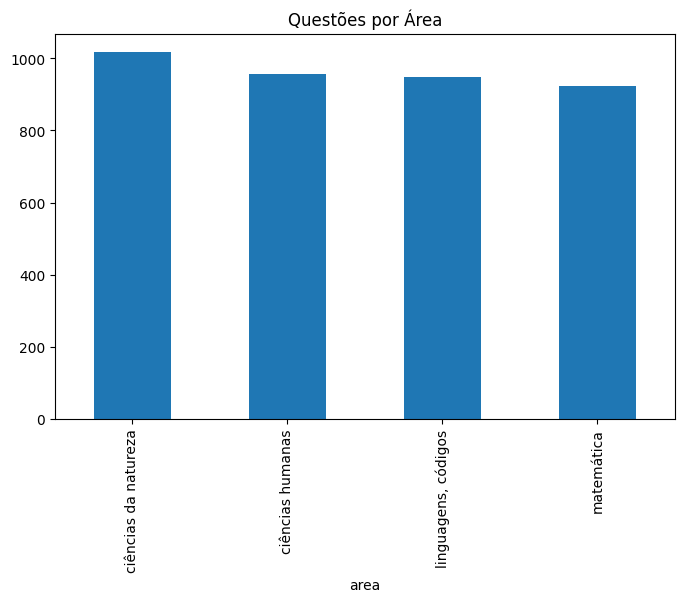

In [4]:
df.groupby('area')['enunciado'].count().plot.bar(figsize=(8, 5))
plt.title('Questões por Área')
plt.show()


In [6]:
import nltk
nltk.download('stopwords')
from nltk.corpus import stopwords
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(min_df=2, encoding='utf-8', ngram_range=(1, 2),
                        stop_words=stopwords.words('portuguese'))

features = tfidf.fit_transform(df['enunciado'].values.astype('U')).toarray()
labels = df['area']
print(features.shape)


[nltk_data] Downloading package stopwords to /usr/share/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


(3843, 41235)


model_name
LinearSVC                 0.940154
LogisticRegression        0.931045
MultinomialNB             0.934168
RandomForestClassifier    0.737953
Name: accuracy, dtype: float64


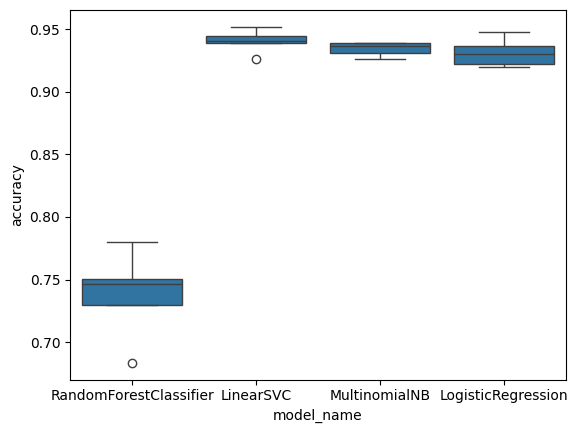

In [7]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.model_selection import cross_val_score
import seaborn as sns

models = [
    RandomForestClassifier(n_estimators=200, max_depth=3, random_state=0),
    LinearSVC(),
    MultinomialNB(),
    LogisticRegression(random_state=0, max_iter=1000),
]

CV = 5
entries = []
for model in models:
    model_name = model.__class__.__name__
    accuracies = cross_val_score(model, features, labels, scoring='accuracy', cv=CV)
    for fold_idx, accuracy in enumerate(accuracies):
        entries.append((model_name, fold_idx, accuracy))

cv_df = pd.DataFrame(entries, columns=['model_name', 'fold_idx', 'accuracy'])
print(cv_df.groupby('model_name').accuracy.mean())

sns.boxplot(x='model_name', y='accuracy', data=cv_df)
plt.show()


In [8]:
df_cn = df[df['area'] == 'ciências da natureza'].copy()
print(f"Total questões: {len(df_cn)}")


Total questões: 1017


In [9]:
keywords = {
    'biologia': [
        'célula', 'dna', 'rna', 'gene', 'genética', 'espécie', 'organismo',
        'proteína', 'mitose', 'meiose', 'fotossíntese', 'ecossistema', 'ecologia',
        'evolução', 'seleção natural', 'vírus', 'bactéria', 'fungo', 'vegetal',
        'tecido', 'digestão', 'hormônio', 'enzima', 'cromossomo', 'alelo',
        'herança', 'biodiversidade', 'membrana', 'mitocôndria', 'cloroplasto',
        'núcleo celular', 'citoplasma', 'população', 'comunidade', 'cadeia alimentar'
    ],
    'fisica': [
        'força', 'velocidade', 'aceleração', 'energia cinética', 'energia potencial',
        'trabalho', 'potência', 'onda', 'frequência', 'comprimento de onda',
        'campo elétrico', 'campo magnético', 'carga elétrica', 'corrente elétrica',
        'resistência elétrica', 'circuito', 'gravitação', 'inércia', 'atrito',
        'termodinâmica', 'óptica', 'refração', 'reflexão', 'lente', 'espelho',
        'cinemática', 'dinâmica', 'hidrostática', 'radioatividade', 'newton',
        'joule', 'watt', 'ampere', 'volt'
    ],
    'quimica': [
        'mol ', 'molécula', 'átomo', 'reação química', 'ácido', 'base', 'sal',
        'solução', 'concentração', 'ligação iônica', 'ligação covalente',
        'tabela periódica', 'valência', 'próton', 'nêutron', 'número atômico',
        'hidrocarboneto', 'alcano', 'álcool', 'aldeído', 'cetona', 'benzeno',
        'polímero', 'combustão', 'oxidação', 'redução', 'ph', 'estequiometria',
        'substância', 'soluto', 'solvente', 'eletrólise', 'pilha'
    ]
}

def rotular_disciplina(texto):
    texto = texto.lower()
    contagens = {d: sum(1 for p in palavras if p in texto)
                 for d, palavras in keywords.items()}
    
    max_count = max(contagens.values())
    if max_count == 0:
        return 'ambigua'
    
    melhores = [d for d, c in contagens.items() if c == max_count]
    if len(melhores) > 1:
        return 'ambigua'
    
    return melhores[0]

df_cn['disciplina'] = df_cn['enunciado'].apply(rotular_disciplina)
print(df_cn['disciplina'].value_counts())


disciplina
quimica     276
ambigua     271
biologia    254
fisica      216
Name: count, dtype: int64


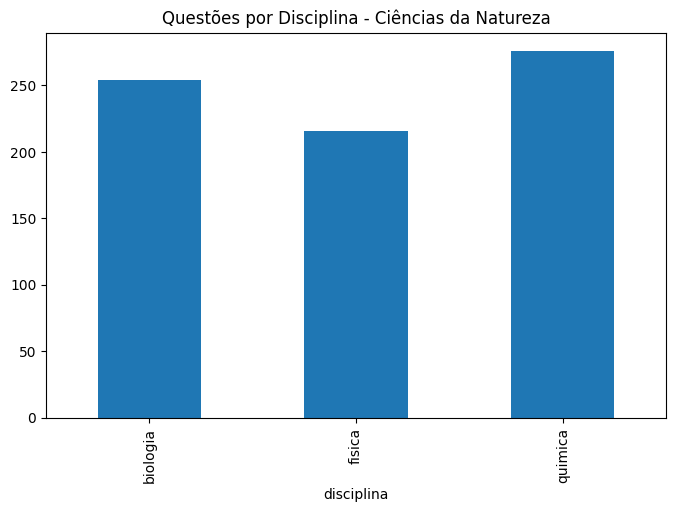

Ambíguas: 271
Prontas para treino: 746


In [10]:
df_cn[df_cn['disciplina'] != 'ambigua'].groupby('disciplina')['enunciado'].count().plot.bar(figsize=(8,5))
plt.title('Questões por Disciplina - Ciências da Natureza')
plt.show()

print(f"Ambíguas: {(df_cn['disciplina'] == 'ambigua').sum()}")
print(f"Prontas para treino: {(df_cn['disciplina'] != 'ambigua').sum()}")


model_name
LinearSVC                 0.857888
LogisticRegression        0.863266
MultinomialNB             0.856546
RandomForestClassifier    0.694345
Name: accuracy, dtype: float64


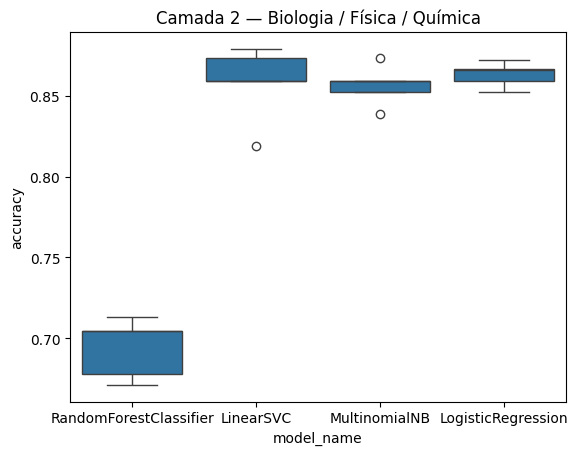

In [11]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import cross_val_score

df_c2 = df_cn[df_cn['disciplina'] != 'ambigua'].copy()

tfidf2 = TfidfVectorizer(min_df=2, encoding='utf-8', ngram_range=(1, 2),
                         stop_words=stopwords.words('portuguese'))

features2 = tfidf2.fit_transform(df_c2['enunciado'].values.astype('U')).toarray()
labels2 = df_c2['disciplina']

entries2 = []
for model in models:
    model_name = model.__class__.__name__
    accuracies = cross_val_score(model, features2, labels2, scoring='accuracy', cv=CV)
    for fold_idx, accuracy in enumerate(accuracies):
        entries2.append((model_name, fold_idx, accuracy))

cv_df2 = pd.DataFrame(entries2, columns=['model_name', 'fold_idx', 'accuracy'])
print(cv_df2.groupby('model_name').accuracy.mean())

sns.boxplot(x='model_name', y='accuracy', data=cv_df2)
plt.title('Camada 2 — Biologia / Física / Química')
plt.show()


In [23]:
df_ch = df[df['area'] == 'ciências humanas'].copy()
print(f"Total questões: {len(df_ch)}")

keywords_ch = {
    'historia': [
        'guerra', 'revolução', 'império', 'república', 'colonização', 'escravidão',
        'industrialização', 'monarquia', 'feudalismo', 'renascimento', 'iluminismo',
        'ditadura', 'democracia', 'nazismo', 'fascismo', 'comunismo',
        'brasil colônia', 'independência', 'abolição', 'proclamação', 'vargas',
        'militar', 'século', 'antiguidade', 'medieval', 'moderno', 'contemporâneo'
    ],
    'geografia': [
        'relevo', 'clima', 'vegetação', 'bioma', 'hidrografia', 'urbanização',
        'migração', 'território', 'fronteira', 'continente', 'latitude', 'longitude',
        'mapa', 'região', 'solo', 'erosão', 'desmatamento', 'sustentabilidade',
        'globalização econômica', 'campo', 'cidade', 'êxodo rural',
        'densidade demográfica', 'pib', 'idh', 'desenvolvimento'
    ],
    'filosofia': [
        'ética', 'moral', 'epistemologia', 'metafísica', 'lógica', 'platão',
        'aristóteles', 'kant', 'descartes', 'sócrates', 'empirismo', 'racionalismo',
        'existencialismo', 'utilitarismo', 'nietzsche', 'hegel', 'rousseau',
        'locke', 'hobbes', 'razão', 'verdade', 'ser', 'conhecimento',
        'virtude', 'contrato social'
    ],
    'sociologia': [
        'sociedade', 'cultura', 'classe social', 'desigualdade', 'capitalismo',
        'socialismo', 'marx', 'weber', 'durkheim', 'movimentos sociais',
        'identidade', 'poder', 'dominação', 'ideologia', 'alienação',
        'estrutura social', 'norma social', 'instituição', 'família', 'religião',
        'etnia', 'racismo', 'preconceito', 'gênero', 'feminismo'
    ]
}

def rotular_humanas(texto):
    texto = texto.lower()
    contagens = {d: sum(1 for p in palavras if p in texto)
                 for d, palavras in keywords_ch.items()}
    max_count = max(contagens.values())
    if max_count == 0:
        return 'ambigua'
    melhores = [d for d, c in contagens.items() if c == max_count]
    if len(melhores) > 1:
        return 'ambigua'
    return melhores[0]

df_ch['disciplina'] = df_ch['enunciado'].apply(rotular_humanas)
print(df_ch['disciplina'].value_counts())


Total questões: 957
disciplina
ambigua       335
geografia     178
filosofia     167
sociologia    155
historia      122
Name: count, dtype: int64


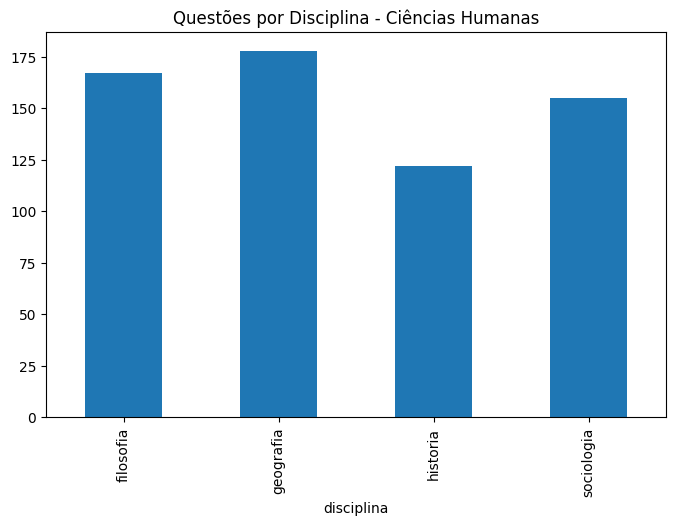

Ambíguas: 335
Prontas para treino: 622


In [24]:
df_ch[df_ch['disciplina'] != 'ambigua'].groupby('disciplina')['enunciado'].count().plot.bar(figsize=(8,5))
plt.title('Questões por Disciplina - Ciências Humanas')
plt.show()

print(f"Ambíguas: {(df_ch['disciplina'] == 'ambigua').sum()}")
print(f"Prontas para treino: {(df_ch['disciplina'] != 'ambigua').sum()}")


model_name
LinearSVC                 0.741097
LogisticRegression        0.704116
MultinomialNB             0.664000
RandomForestClassifier    0.536968
Name: accuracy, dtype: float64


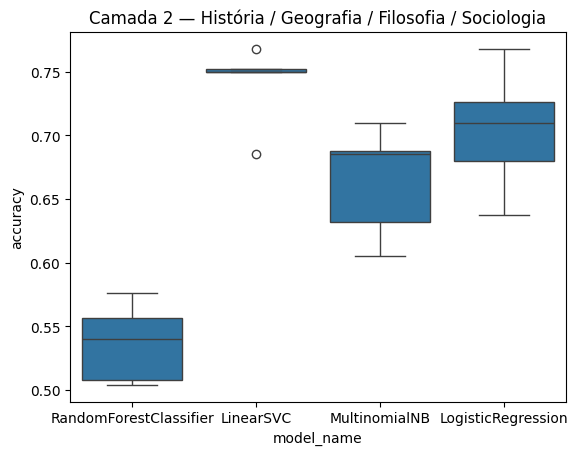

In [25]:
df_c2h = df_ch[df_ch['disciplina'] != 'ambigua'].copy()

tfidf_ch = TfidfVectorizer(min_df=2, encoding='utf-8', ngram_range=(1, 2),
                            stop_words=stopwords.words('portuguese'))

features_ch = tfidf_ch.fit_transform(df_c2h['enunciado'].values.astype('U')).toarray()
labels_ch = df_c2h['disciplina']

entries_ch = []
for model in models:
    model_name = model.__class__.__name__
    accuracies = cross_val_score(model, features_ch, labels_ch, scoring='accuracy', cv=CV)
    for fold_idx, accuracy in enumerate(accuracies):
        entries_ch.append((model_name, fold_idx, accuracy))

cv_df_ch = pd.DataFrame(entries_ch, columns=['model_name', 'fold_idx', 'accuracy'])
print(cv_df_ch.groupby('model_name').accuracy.mean())

sns.boxplot(x='model_name', y='accuracy', data=cv_df_ch)
plt.title('Camada 2 — História / Geografia / Filosofia / Sociologia')
plt.show()


In [26]:
df_lc = df[df['area'] == 'linguagens, códigos'].copy()
print(f"Total questões: {len(df_lc)}")

keywords_lc = {
    'portugues': [
        'gramática', 'sintaxe', 'morfologia', 'semântica', 'fonologia',
        'sujeito', 'predicado', 'objeto direto', 'objeto indireto',
        'coesão', 'coerência', 'argumentação', 'redação', 'dissertação',
        'variedade linguística', 'norma culta', 'linguagem formal',
        'verbo', 'substantivo', 'adjetivo', 'advérbio', 'pronome',
        'conjunção', 'período composto', 'oração subordinada',
        'pontuação', 'ortografia', 'concordância', 'regência'
    ],
    'literatura': [
        'machado de assis', 'guimarães rosa', 'clarice lispector', 'drummond',
        'fernando pessoa', 'camões', 'josé de alencar', 'lima barreto',
        'romantismo', 'realismo', 'modernismo', 'parnasianismo', 'simbolismo',
        'barroco', 'arcadismo', 'naturalismo', 'quinhentismo',
        'romance', 'conto', 'crônica', 'poesia', 'soneto',
        'personagem', 'narrador', 'enredo', 'movimento literário',
        'obra literária', 'autor', 'escritor', 'poeta'
    ],
    'ingles': [
        'english', 'reading', 'vocabulary', 'text', 'language',
        'verb', 'noun', 'adjective', 'pronoun', 'sentence',
        'translation', 'meaning', 'word', 'grammar english',
        'the ', ' is ', ' are ', ' was ', ' were '
    ],
    'artes': [
        'pintura', 'escultura', 'arquitetura', 'música', 'dança', 'teatro',
        'impressionismo', 'cubismo', 'expressionismo', 'surrealismo',
        'obra de arte', 'artista plástico', 'movimento artístico',
        'cinema', 'fotografia', 'arte contemporânea', 'arte moderna',
        'instrumento musical', 'composição musical', 'ritmo', 'melodia'
    ]
}

def rotular_linguagens(texto):
    texto = texto.lower()
    contagens = {d: sum(1 for p in palavras if p in texto)
                 for d, palavras in keywords_lc.items()}
    max_count = max(contagens.values())
    if max_count == 0:
        return 'ambigua'
    melhores = [d for d, c in contagens.items() if c == max_count]
    if len(melhores) > 1:
        return 'ambigua'
    return melhores[0]

df_lc['disciplina'] = df_lc['enunciado'].apply(rotular_linguagens)
print(df_lc['disciplina'].value_counts())


Total questões: 947
disciplina
ambigua       406
ingles        261
literatura    167
artes          77
portugues      36
Name: count, dtype: int64


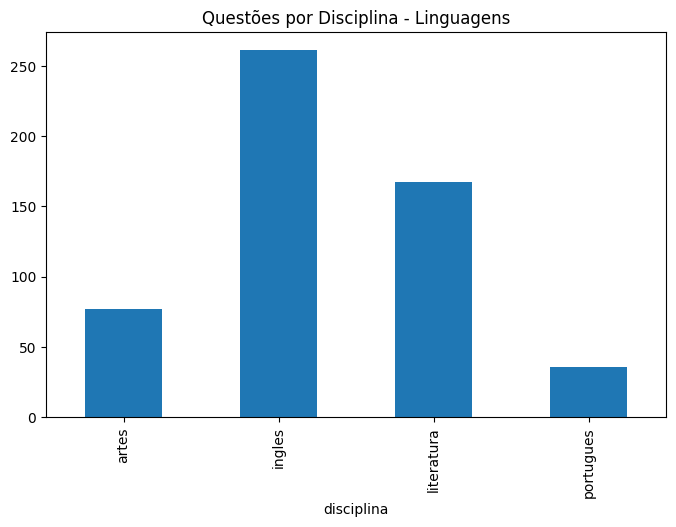

Ambíguas: 406
Prontas para treino: 541


In [27]:
df_lc[df_lc['disciplina'] != 'ambigua'].groupby('disciplina')['enunciado'].count().plot.bar(figsize=(8,5))
plt.title('Questões por Disciplina - Linguagens')
plt.show()

print(f"Ambíguas: {(df_lc['disciplina'] == 'ambigua').sum()}")
print(f"Prontas para treino: {(df_lc['disciplina'] != 'ambigua').sum()}")


model_name
LinearSVC                 0.702497
LogisticRegression        0.639585
MultinomialNB             0.615579
RandomForestClassifier    0.502803
Name: accuracy, dtype: float64


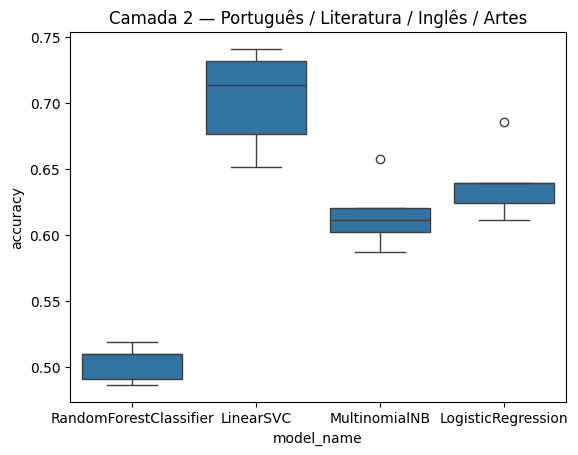

In [28]:
df_c2_lc = df_lc[df_lc['disciplina'] != 'ambigua'].copy()

tfidf_lc = TfidfVectorizer(min_df=2, encoding='utf-8', ngram_range=(1, 2),
                            stop_words=stopwords.words('portuguese'))

features_lc = tfidf_lc.fit_transform(df_c2_lc['enunciado'].values.astype('U')).toarray()
labels_lc = df_c2_lc['disciplina']

entries_lc = []
for model in models:
    model_name = model.__class__.__name__
    accuracies = cross_val_score(model, features_lc, labels_lc, scoring='accuracy', cv=CV)
    for fold_idx, accuracy in enumerate(accuracies):
        entries_lc.append((model_name, fold_idx, accuracy))

cv_df_lc = pd.DataFrame(entries_lc, columns=['model_name', 'fold_idx', 'accuracy'])
print(cv_df_lc.groupby('model_name').accuracy.mean())

sns.boxplot(x='model_name', y='accuracy', data=cv_df_lc)
plt.title('Camada 2 — Português / Literatura / Inglês / Artes')
plt.show()


In [29]:
# Keywords por disciplina e tópico
keywords_layer3 = {
    'biologia': {
        'genetica': [
            'dna', 'rna', 'gene', 'genética', 'cromossomo', 'alelo', 'herança',
            'dominante', 'recessivo', 'mutação', 'genótipo', 'fenótipo',
            'mendel', 'hereditariedade', 'nucleotídeo', 'código genético', 'meiose'
        ],
        'ecologia': [
            'ecossistema', 'cadeia alimentar', 'teia alimentar', 'biodiversidade',
            'habitat', 'nicho ecológico', 'predador', 'presa', 'parasitismo',
            'mutualismo', 'ciclo do carbono', 'extinção', 'produtor', 'consumidor',
            'decompositor', 'bioma', 'população', 'comunidade ecológica'
        ],
        'citologia': [
            'membrana celular', 'mitocôndria', 'cloroplasto', 'ribossomo',
            'retículo endoplasmático', 'complexo de golgi', 'lisossomo',
            'núcleo celular', 'citoplasma', 'mitose', 'organela',
            'célula eucariota', 'célula procariota', 'osmose', 'difusão'
        ],
        'fisiologia': [
            'digestão', 'sistema digestório', 'sistema circulatório',
            'sistema respiratório', 'sistema nervoso', 'neurônio',
            'hormônio', 'sistema endócrino', 'anticorpo', 'antígeno',
            'sangue', 'coração', 'pulmão', 'rim', 'sistema excretor'
        ],
        'evolucao': [
            'seleção natural', 'darwin', 'evolução', 'adaptação', 'especiação',
            'ancestral comum', 'árvore filogenética', 'deriva genética',
            'lamarck', 'variação genética', 'fóssil', 'homologia'
        ]
    },
    'fisica': {
        'mecanica': [
            'força', 'velocidade', 'aceleração', 'massa', 'movimento',
            'inércia', 'gravitação', 'newton', 'trabalho mecânico',
            'energia cinética', 'energia potencial', 'atrito', 'impulso',
            'quantidade de movimento', 'torque', 'equilíbrio mecânico'
        ],
        'termodinamica': [
            'calor', 'temperatura', 'entropia', 'dilatação', 'gás ideal',
            'pressão', 'termodinâmica', 'primeira lei', 'segunda lei',
            'ciclo de carnot', 'condução', 'convecção', 'irradiação',
            'capacidade calorífica', 'calor específico'
        ],
        'eletromagnetismo': [
            'campo elétrico', 'campo magnético', 'corrente elétrica',
            'circuito elétrico', 'resistência elétrica', 'tensão elétrica',
            'lei de ohm', 'potência elétrica', 'capacitor', 'indutor',
            'transformador', 'força magnética', 'indução eletromagnética'
        ],
        'optica': [
            'luz', 'reflexão', 'refração', 'lente', 'espelho',
            'índice de refração', 'dispersão da luz', 'cor', 'sombra',
            'penumbra', 'câmara escura', 'olho humano', 'óculos'
        ],
        'ondulatoria': [
            'onda', 'frequência', 'comprimento de onda', 'som',
            'amplitude', 'período', 'velocidade do som', 'ultrassom',
            'infrassom', 'ressonância', 'interferência', 'efeito doppler'
        ]
    },
    'quimica': {
        'organica': [
            'hidrocarboneto', 'alcano', 'alceno', 'alcino', 'álcool',
            'aldeído', 'cetona', 'ácido carboxílico', 'éster', 'amina',
            'benzeno', 'polímero', 'plástico', 'combustão orgânica',
            'isomeria', 'função orgânica', 'cadeia carbônica'
        ],
        'inorganica': [
            'ácido', 'base', 'sal inorgânico', 'óxido', 'neutralização',
            'reação inorgânica', 'ph', 'indicador ácido', 'titulação',
            'arrhenius', 'brønsted', 'hidrólise', 'solução tampão'
        ],
        'fisico_quimica': [
            'mol', 'estequiometria', 'equilíbrio químico', 'cinética química',
            'termoquímica', 'entalpia', 'pilha', 'eletrólise', 'eletroquímica',
            'propriedades coligativas', 'solução', 'concentração molar',
            'pressão osmótica', 'lei de hess'
        ],
        'estrutura_atomica': [
            'átomo', 'tabela periódica', 'elemento químico', 'próton',
            'nêutron', 'elétron', 'número atômico', 'número de massa',
            'isótopo', 'ligação iônica', 'ligação covalente', 'ligação metálica',
            'eletronegatividade', 'camada eletrônica', 'orbital'
        ]
    }
}

# Função genérica de rotulagem
def rotular_topico(texto, keywords_disc):
    texto = texto.lower()
    contagens = {t: sum(1 for p in palavras if p in texto)
                 for t, palavras in keywords_disc.items()}
    max_count = max(contagens.values())
    if max_count == 0:
        return 'ambigua'
    melhores = [t for t, c in contagens.items() if c == max_count]
    if len(melhores) > 1:
        return 'ambigua'
    return melhores[0]

# Aplicar rotulagem
df_cn.loc[df_cn['disciplina'] == 'biologia', 'topico'] = \
    df_cn[df_cn['disciplina'] == 'biologia']['enunciado'].apply(
        lambda x: rotular_topico(x, keywords_layer3['biologia']))

df_cn.loc[df_cn['disciplina'] == 'fisica', 'topico'] = \
    df_cn[df_cn['disciplina'] == 'fisica']['enunciado'].apply(
        lambda x: rotular_topico(x, keywords_layer3['fisica']))

df_cn.loc[df_cn['disciplina'] == 'quimica', 'topico'] = \
    df_cn[df_cn['disciplina'] == 'quimica']['enunciado'].apply(
        lambda x: rotular_topico(x, keywords_layer3['quimica']))

print("Biologia:")
print(df_cn[df_cn['disciplina'] == 'biologia']['topico'].value_counts())
print("\nFísica:")
print(df_cn[df_cn['disciplina'] == 'fisica']['topico'].value_counts())
print("\nQuímica:")
print(df_cn[df_cn['disciplina'] == 'quimica']['topico'].value_counts())


Biologia:
topico
ambigua       81
genetica      80
ecologia      43
fisiologia    32
citologia      9
evolucao       9
Name: count, dtype: int64

Física:
topico
mecanica            68
ambigua             55
ondulatoria         40
optica              28
eletromagnetismo    16
termodinamica        9
Name: count, dtype: int64

Química:
topico
ambigua              105
inorganica            68
fisico_quimica        47
organica              41
estrutura_atomica     15
Name: count, dtype: int64



=== BIOLOGIA ===
model_name
LinearSVC                 0.646555
LogisticRegression        0.560504
MultinomialNB             0.554622
RandomForestClassifier    0.468235
Name: accuracy, dtype: float64


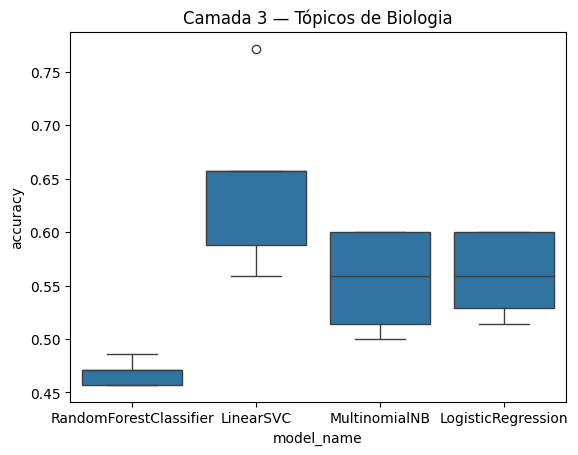


=== FISICA ===
model_name
LinearSVC                 0.857008
LogisticRegression        0.689583
MultinomialNB             0.696023
RandomForestClassifier    0.534659
Name: accuracy, dtype: float64


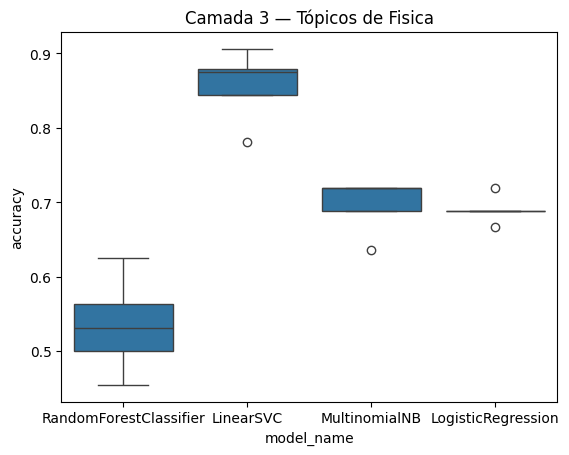


=== QUIMICA ===
model_name
LinearSVC                 0.684706
LogisticRegression        0.596975
MultinomialNB             0.579328
RandomForestClassifier    0.450588
Name: accuracy, dtype: float64


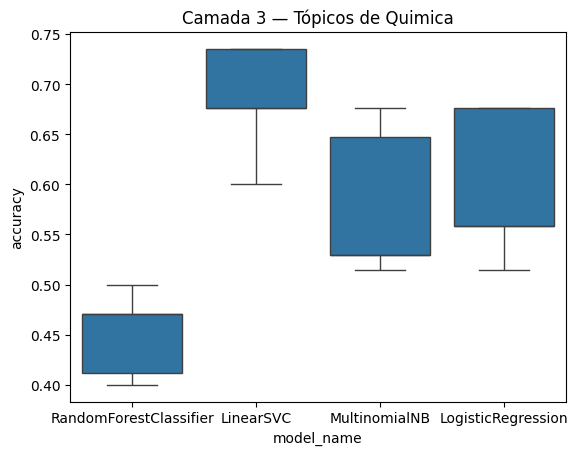


=== RESUMO CAMADA 3 ===

BIOLOGIA — melhor: 0.647 (LinearSVC)

FISICA — melhor: 0.857 (LinearSVC)

QUIMICA — melhor: 0.685 (LinearSVC)


In [30]:
resultados_layer3 = {}

for disciplina in ['biologia', 'fisica', 'quimica']:
    df_disc = df_cn[(df_cn['disciplina'] == disciplina) & 
                    (df_cn['topico'] != 'ambigua')].copy()
    
    if len(df_disc) < 20:
        print(f"{disciplina}: poucos dados, pulando.")
        continue

    tfidf_d = TfidfVectorizer(min_df=2, encoding='utf-8', ngram_range=(1, 2),
                               stop_words=stopwords.words('portuguese'))
    features_d = tfidf_d.fit_transform(df_disc['enunciado'].values.astype('U')).toarray()
    labels_d = df_disc['topico']

    entries_d = []
    for model in models:
        model_name = model.__class__.__name__
        accuracies = cross_val_score(model, features_d, labels_d,
                                     scoring='accuracy', cv=CV)
        for fold_idx, accuracy in enumerate(accuracies):
            entries_d.append((model_name, fold_idx, accuracy))

    cv_d = pd.DataFrame(entries_d, columns=['model_name', 'fold_idx', 'accuracy'])
    melhor = cv_d.groupby('model_name').accuracy.mean()
    resultados_layer3[disciplina] = melhor
    
    print(f"\n=== {disciplina.upper()} ===")
    print(melhor)
    
    sns.boxplot(x='model_name', y='accuracy', data=cv_d)
    plt.title(f'Camada 3 — Tópicos de {disciplina.capitalize()}')
    plt.show()

print("\n=== RESUMO CAMADA 3 ===")
for disc, resultado in resultados_layer3.items():
    print(f"\n{disc.upper()} — melhor: {resultado.max():.3f} ({resultado.idxmax()})")


In [31]:
keywords_layer3_humanas = {
    'historia': {
        'brasil_colonial': [
            'capitanias', 'sesmarias', 'pau-brasil', 'jesuítas', 'bandeirantes',
            'ciclo do ouro', 'escravidão colonial', 'colônia', 'metrópole',
            'pacto colonial', 'engenho', 'açúcar'
        ],
        'brasil_republicano': [
            'república velha', 'era vargas', 'estado novo', 'ditadura militar',
            'redemocratização', 'coronelismo', 'tenentismo', 'constituição',
            'getúlio', 'diretas já', 'abertura política'
        ],
        'historia_mundial': [
            'segunda guerra', 'primeira guerra', 'guerra fria', 'holocausto',
            'revolução francesa', 'revolução russa', 'nazismo', 'fascismo',
            'imperialismo europeu', 'descolonização', 'onu', 'otan'
        ],
        'brasil_imperial': [
            'dom pedro', 'segundo reinado', 'abolição', 'lei áurea',
            'monarquia', 'independência do brasil', 'período regencial',
            'café com leite', 'princesa isabel'
        ]
    },
    'geografia': {
        'geografia_fisica': [
            'relevo', 'planalto', 'planície', 'depressão', 'hidrografia',
            'bacia hidrográfica', 'solo', 'erosão', 'intemperismo',
            'clima', 'temperatura', 'precipitação', 'latitude'
        ],
        'meio_ambiente': [
            'desmatamento', 'aquecimento global', 'efeito estufa',
            'sustentabilidade', 'poluição', 'biodiversidade', 'área de preservação',
            'amazônia', 'cerrado', 'mata atlântica', 'queimadas'
        ],
        'geografia_humana': [
            'urbanização', 'êxodo rural', 'migração', 'densidade demográfica',
            'metrópole', 'favela', 'segregação urbana', 'crescimento populacional',
            'transição demográfica', 'índice de urbanização'
        ],
        'geopolitica': [
            'globalização', 'países desenvolvidos', 'países subdesenvolvidos',
            'idh', 'pib', 'bloco econômico', 'mercosul', 'união europeia',
            'geopolítica', 'fronteira', 'território', 'soberania'
        ]
    },
    'filosofia': {
        'filosofia_antiga': [
            'sócrates', 'platão', 'aristóteles', 'estoicismo', 'epicurismo',
            'sofistas', 'pré-socráticos', 'alma', 'ideia', 'forma',
            'virtude', 'bem', 'polis', 'república platônica'
        ],
        'filosofia_moderna': [
            'descartes', 'locke', 'hume', 'kant', 'rousseau', 'hobbes',
            'empirismo', 'racionalismo', 'iluminismo', 'contrato social',
            'cogito', 'razão pura', 'imperativo categórico'
        ],
        'filosofia_contemporanea': [
            'nietzsche', 'hegel', 'existencialismo', 'sartre', 'fenomenologia',
            'positivismo', 'pragmatismo', 'marxismo filosófico',
            'super-homem', 'dialética', 'ser e nada'
        ],
        'etica_politica': [
            'ética', 'moral', 'justiça', 'democracia', 'direito natural',
            'utilitarismo', 'deontologia', 'bem comum', 'liberdade',
            'igualdade', 'cidadania', 'direitos fundamentais'
        ]
    },
    'sociologia': {
        'classicos_sociologia': [
            'durkheim', 'weber', 'marx', 'fato social', 'anomia',
            'solidariedade', 'ação social', 'materialismo histórico',
            'mais-valia', 'funcionalismo', 'burocracia'
        ],
        'temas_sociais': [
            'desigualdade social', 'exclusão social', 'racismo',
            'feminismo', 'movimentos sociais', 'direitos humanos',
            'violência', 'pobreza', 'classe social', 'mobilidade social'
        ],
        'cultura_identidade': [
            'cultura', 'identidade', 'etnia', 'diversidade cultural',
            'indústria cultural', 'mídia', 'globalização cultural',
            'etnocentrismo', 'relativismo cultural', 'sincretismo'
        ],
        'poder_estado': [
            'poder', 'estado', 'ideologia', 'hegemonia', 'dominação',
            'gramsci', 'foucault', 'bourdieu', 'capital social',
            'controle social', 'instituição', 'aparelho ideológico'
        ]
    }
}

def rotular_topico(texto, keywords_disc):
    texto = texto.lower()
    contagens = {t: sum(1 for p in palavras if p in texto)
                 for t, palavras in keywords_disc.items()}
    max_count = max(contagens.values())
    if max_count == 0:
        return 'ambigua'
    melhores = [t for t, c in contagens.items() if c == max_count]
    if len(melhores) > 1:
        return 'ambigua'
    return melhores[0]

for disciplina in ['historia', 'geografia', 'filosofia', 'sociologia']:
    mask = df_ch['disciplina'] == disciplina
    df_ch.loc[mask, 'topico'] = df_ch[mask]['enunciado'].apply(
        lambda x: rotular_topico(x, keywords_layer3_humanas[disciplina]))

for disciplina in ['historia', 'geografia', 'filosofia', 'sociologia']:
    print(f"\n{disciplina.upper()}:")
    print(df_ch[df_ch['disciplina'] == disciplina]['topico'].value_counts())



HISTORIA:
topico
ambigua               72
historia_mundial      22
brasil_republicano    12
brasil_imperial       11
brasil_colonial        5
Name: count, dtype: int64

GEOGRAFIA:
topico
ambigua             71
geografia_fisica    40
geopolitica         31
geografia_humana    21
meio_ambiente       15
Name: count, dtype: int64

FILOSOFIA:
topico
ambigua              66
filosofia_antiga     63
etica_politica       31
filosofia_moderna     7
Name: count, dtype: int64

SOCIOLOGIA:
topico
ambigua                 50
poder_estado            47
cultura_identidade      45
classicos_sociologia     7
temas_sociais            6
Name: count, dtype: int64


In [33]:
keywords_layer3_linguagens = {
    'literatura': {
        'literatura_brasileira': [
            'machado de assis', 'guimarães rosa', 'clarice lispector',
            'drummond', 'lima barreto', 'josé de alencar', 'aluísio azevedo',
            'modernismo brasileiro', 'semana de arte moderna', 'regionalismo'
        ],
        'literatura_portuguesa': [
            'camões', 'fernando pessoa', 'eça de queirós', 'bocage',
            'lusíadas', 'heterônimo', 'saudade', 'literatura portuguesa'
        ],
        'movimentos_literarios': [
            'romantismo', 'realismo', 'naturalismo', 'simbolismo',
            'parnasianismo', 'barroco', 'arcadismo', 'modernismo literário',
            'vanguarda', 'concretismo', 'geração de 45'
        ],
        'generos_literarios': [
            'romance', 'conto', 'crônica', 'poesia', 'soneto', 'épico',
            'lírico', 'dramático', 'narrador', 'personagem', 'enredo',
            'clímax', 'desfecho', 'foco narrativo'
        ]
    },
    'portugues': {
        'gramatica': [
            'sujeito', 'predicado', 'objeto direto', 'objeto indireto',
            'adjunto adverbial', 'concordância verbal', 'concordância nominal',
            'regência', 'crase', 'pronome relativo', 'oração subordinada'
        ],
        'redacao_texto': [
            'dissertação', 'argumentação', 'tese', 'coesão', 'coerência',
            'gênero textual', 'tipo textual', 'narração', 'descrição',
            'proposta de intervenção', 'introdução', 'conclusão'
        ],
        'linguistica': [
            'semântica', 'pragmática', 'variação linguística', 'norma culta',
            'linguagem formal', 'linguagem informal', 'intertextualidade',
            'polifonia', 'ironia', 'metáfora', 'figuras de linguagem'
        ]
    },
    'artes': {
        'artes_visuais': [
            'pintura', 'escultura', 'arquitetura', 'gravura', 'desenho',
            'impressionismo', 'cubismo', 'expressionismo', 'surrealismo',
            'obra de arte', 'artista plástico', 'tela', 'perspectiva'
        ],
        'musica_danca': [
            'música', 'ritmo', 'melodia', 'harmonia', 'instrumento musical',
            'dança', 'coreografia', 'ballet', 'samba', 'forró', 'mpb'
        ]
    }
}

for disciplina in ['literatura', 'portugues', 'artes']:
    mask = df_lc['disciplina'] == disciplina
    df_lc.loc[mask, 'topico'] = df_lc[mask]['enunciado'].apply(
        lambda x: rotular_topico(x, keywords_layer3_linguagens[disciplina]))

for disciplina in ['literatura', 'portugues', 'artes']:
    print(f"\n{disciplina.upper()}:")
    print(df_lc[df_lc['disciplina'] == disciplina]['topico'].value_counts())



LITERATURA:
topico
generos_literarios       105
ambigua                   55
literatura_brasileira      5
movimentos_literarios      2
Name: count, dtype: int64

PORTUGUES:
topico
ambigua          16
gramatica         9
redacao_texto     7
linguistica       4
Name: count, dtype: int64

ARTES:
topico
musica_danca     41
artes_visuais    24
ambigua          12
Name: count, dtype: int64


In [34]:
resultados_layer3_completo = {}

# Ciências Humanas
for disciplina in ['historia', 'geografia', 'filosofia', 'sociologia']:
    df_disc = df_ch[(df_ch['disciplina'] == disciplina) &
                    (df_ch['topico'] != 'ambigua')].copy()

    if len(df_disc) < 30:
        print(f"{disciplina}: poucos dados ({len(df_disc)}), pulando.")
        continue

    tfidf_d = TfidfVectorizer(min_df=2, encoding='utf-8', ngram_range=(1, 2),
                               stop_words=stopwords.words('portuguese'))
    features_d = tfidf_d.fit_transform(df_disc['enunciado'].values.astype('U')).toarray()
    labels_d = df_disc['topico']

    entries_d = []
    for model in models:
        model_name = model.__class__.__name__
        accuracies = cross_val_score(model, features_d, labels_d,
                                     scoring='accuracy', cv=CV)
        for fold_idx, accuracy in enumerate(accuracies):
            entries_d.append((model_name, fold_idx, accuracy))

    cv_d = pd.DataFrame(entries_d, columns=['model_name', 'fold_idx', 'accuracy'])
    resultados_layer3_completo[disciplina] = cv_d.groupby('model_name').accuracy.mean()
    print(f"\n=== {disciplina.upper()} ===")
    print(resultados_layer3_completo[disciplina])

# Linguagens
for disciplina in ['literatura', 'portugues', 'artes']:
    df_disc = df_lc[(df_lc['disciplina'] == disciplina) &
                    (df_lc['topico'] != 'ambigua')].copy()

    if len(df_disc) < 30:
        print(f"{disciplina}: poucos dados ({len(df_disc)}), pulando.")
        continue

    tfidf_d = TfidfVectorizer(min_df=2, encoding='utf-8', ngram_range=(1, 2),
                               stop_words=stopwords.words('portuguese'))
    features_d = tfidf_d.fit_transform(df_disc['enunciado'].values.astype('U')).toarray()
    labels_d = df_disc['topico']

    entries_d = []
    for model in models:
        model_name = model.__class__.__name__
        accuracies = cross_val_score(model, features_d, labels_d,
                                     scoring='accuracy', cv=CV)
        for fold_idx, accuracy in enumerate(accuracies):
            entries_d.append((model_name, fold_idx, accuracy))

    cv_d = pd.DataFrame(entries_d, columns=['model_name', 'fold_idx', 'accuracy'])
    resultados_layer3_completo[disciplina] = cv_d.groupby('model_name').accuracy.mean()
    print(f"\n=== {disciplina.upper()} ===")
    print(resultados_layer3_completo[disciplina])

print("\n\n=== RESUMO FINAL CAMADA 3 ===")
for disc, resultado in resultados_layer3_completo.items():
    print(f"{disc.upper():<20} melhor: {resultado.max():.3f} ({resultado.idxmax()})")



=== HISTORIA ===
model_name
LinearSVC                 0.60
LogisticRegression        0.48
MultinomialNB             0.50
RandomForestClassifier    0.46
Name: accuracy, dtype: float64

=== GEOGRAFIA ===
model_name
LinearSVC                 0.672727
LogisticRegression        0.523810
MultinomialNB             0.523810
RandomForestClassifier    0.430303
Name: accuracy, dtype: float64

=== FILOSOFIA ===
model_name
LinearSVC                 0.73381
LogisticRegression        0.64381
MultinomialNB             0.65381
RandomForestClassifier    0.62381
Name: accuracy, dtype: float64

=== SOCIOLOGIA ===
model_name
LinearSVC                 0.685714
LogisticRegression        0.647619
MultinomialNB             0.638095
RandomForestClassifier    0.685714
Name: accuracy, dtype: float64


/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_split.py:805: UserWarning: The least populated class in y has only 2 members, which is less than n_splits=5.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_split.py:805: UserWarning: The least populated class in y has only 2 members, which is less than n_splits=5.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_split.py:805: UserWarning: The least populated class in y has only 2 members, which is less than n_splits=5.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_split.py:805: UserWarning: The least populated class in y has only 2 members, which is less than n_splits=5.
  warnings.warn(



=== LITERATURA ===
model_name
LinearSVC                 0.937945
LogisticRegression        0.937945
MultinomialNB             0.937945
RandomForestClassifier    0.937945
Name: accuracy, dtype: float64
portugues: poucos dados (20), pulando.

=== ARTES ===
model_name
LinearSVC                 0.846154
LogisticRegression        0.646154
MultinomialNB             0.753846
RandomForestClassifier    0.661538
Name: accuracy, dtype: float64


=== RESUMO FINAL CAMADA 3 ===
HISTORIA             melhor: 0.600 (LinearSVC)
GEOGRAFIA            melhor: 0.673 (LinearSVC)
FILOSOFIA            melhor: 0.734 (LinearSVC)
SOCIOLOGIA           melhor: 0.686 (LinearSVC)
LITERATURA           melhor: 0.938 (LinearSVC)
ARTES                melhor: 0.846 (LinearSVC)


In [35]:
from sklearn.svm import LinearSVC
from sklearn.feature_extraction.text import TfidfVectorizer
from nltk.corpus import stopwords

modelos = {}

def treinar_modelo(df_treino, coluna_texto, coluna_label):
    tfidf = TfidfVectorizer(min_df=2, encoding='utf-8', ngram_range=(1, 2),
                            stop_words=stopwords.words('portuguese'))
    X = tfidf.fit_transform(df_treino[coluna_texto].values.astype('U'))
    y = df_treino[coluna_label]
    modelo = LinearSVC()
    modelo.fit(X, y)
    return {'modelo': modelo, 'tfidf': tfidf}

# Camada 1
modelos['camada1'] = treinar_modelo(df, 'enunciado', 'area')
print("Camada 1 treinada")

# Camada 2 - Ciências da Natureza
modelos['ciências da natureza'] = treinar_modelo(
    df_cn[df_cn['disciplina'] != 'ambigua'], 'enunciado', 'disciplina')
print("Camada 2 CN treinada")

# Camada 2 - Ciências Humanas
modelos['ciências humanas'] = treinar_modelo(
    df_ch[df_ch['disciplina'] != 'ambigua'], 'enunciado', 'disciplina')
print("Camada 2 CH treinada")

# Camada 2 - Linguagens
modelos['linguagens, códigos'] = treinar_modelo(
    df_lc[df_lc['disciplina'] != 'ambigua'], 'enunciado', 'disciplina')
print("Camada 2 LC treinada")

# Camada 3 - por disciplina
for disciplina in ['biologia', 'fisica', 'quimica']:
    df_d = df_cn[(df_cn['disciplina'] == disciplina) & (df_cn['topico'] != 'ambigua')]
    if len(df_d) >= 30:
        modelos[disciplina] = treinar_modelo(df_d, 'enunciado', 'topico')
        print(f"Camada 3 {disciplina} treinada")

for disciplina in ['historia', 'geografia', 'filosofia', 'sociologia']:
    df_d = df_ch[(df_ch['disciplina'] == disciplina) & (df_ch['topico'] != 'ambigua')]
    if len(df_d) >= 30:
        modelos[disciplina] = treinar_modelo(df_d, 'enunciado', 'topico')
        print(f"Camada 3 {disciplina} treinada")

for disciplina in ['literatura', 'artes']:
    df_d = df_lc[(df_lc['disciplina'] == disciplina) & (df_lc['topico'] != 'ambigua')]
    if len(df_d) >= 30:
        modelos[disciplina] = treinar_modelo(df_d, 'enunciado', 'topico')
        print(f"Camada 3 {disciplina} treinada")

print("\nTodos os modelos prontos!")
print(f"Modelos disponíveis: {list(modelos.keys())}")


Camada 1 treinada
Camada 2 CN treinada
Camada 2 CH treinada
Camada 2 LC treinada
Camada 3 biologia treinada
Camada 3 fisica treinada
Camada 3 quimica treinada
Camada 3 historia treinada
Camada 3 geografia treinada
Camada 3 filosofia treinada
Camada 3 sociologia treinada
Camada 3 literatura treinada
Camada 3 artes treinada

Todos os modelos prontos!
Modelos disponíveis: ['camada1', 'ciências da natureza', 'ciências humanas', 'linguagens, códigos', 'biologia', 'fisica', 'quimica', 'historia', 'geografia', 'filosofia', 'sociologia', 'literatura', 'artes']


In [37]:
def classificar(questao):
    resultado = {}

    # Camada 1 — área
    tfidf1 = modelos['camada1']['tfidf']
    modelo1 = modelos['camada1']['modelo']
    area = modelo1.predict(tfidf1.transform([questao]))[0]
    resultado['area'] = area

    # Camada 2 — disciplina
    if area in modelos:
        tfidf2 = modelos[area]['tfidf']
        modelo2 = modelos[area]['modelo']
        disciplina = modelo2.predict(tfidf2.transform([questao]))[0]
        resultado['disciplina'] = disciplina
    else:
        resultado['disciplina'] = 'não classificado'
        resultado['topico'] = 'não classificado'
        return resultado

    # Camada 3 — tópico
    if disciplina in modelos:
        tfidf3 = modelos[disciplina]['tfidf']
        modelo3 = modelos[disciplina]['modelo']
        topico = modelo3.predict(tfidf3.transform([questao]))[0]
        resultado['topico'] = topico
    else:
        resultado['topico'] = 'não classificado'

    return resultado


# Testar com exemplos
questoes_teste = [
    "A mitose é um processo de divisão celular que resulta em células filhas geneticamente idênticas.",
    "Um corpo de massa 5kg é submetido a uma força de 10N. Calcule a aceleração.",
    "A Revolução Francesa de 1789 marcou o fim do Absolutismo na Europa.",
    "Os hidrocarbonetos são compostos orgânicos formados apenas por carbono e hidrogênio."
]

for q in questoes_teste:
    r = classificar(q)
    print(f"\nQuestão: {q[:60]}...")
    print(f"  Área:       {r['area']}")
    print(f"  Disciplina: {r['disciplina']}")
    print(f"  Tópico:     {r['topico']}")



Questão: A mitose é um processo de divisão celular que resulta em cél...
  Área:       ciências da natureza
  Disciplina: biologia
  Tópico:     genetica

Questão: Um corpo de massa 5kg é submetido a uma força de 10N. Calcul...
  Área:       ciências da natureza
  Disciplina: fisica
  Tópico:     mecanica

Questão: A Revolução Francesa de 1789 marcou o fim do Absolutismo na ...
  Área:       ciências humanas
  Disciplina: historia
  Tópico:     historia_mundial

Questão: Os hidrocarbonetos são compostos orgânicos formados apenas p...
  Área:       ciências da natureza
  Disciplina: quimica
  Tópico:     organica
